# 🌲 Tema 24: Ensambles - Consenso y Potenciación

¡Bienvenido/a a los algoritmos ganadores de competencias de Machine Learning!

En el módulo anterior aprendimos que un Árbol de Decisión es sumamente interpretable, pero sufre de un problema grave: es propenso al *Overfitting* (memorizar los datos) y es muy sensible a pequeños cambios. 

Para resolver esto, nacieron los **Métodos de Ensamble**, los cuales combinan decenas o cientos de modelos (generalmente árboles) para que, trabajando en equipo, corrijan los errores de los demás y logren una precisión predictiva insuperable.

## 🚀 Contenido del Cuaderno

1. **Teoría de Ensambles:** Bagging vs. Boosting.
2. **Preprocesamiento con LabelEncoder:** Transformación categórica.
3. **Random Forest:** Consenso, varianza e Importancia de Características.
4. **Gradient Boosting y AdaBoost:** Potenciación mediante aprendizaje de errores.
5. **Proyecto Práctico:** Selección algorítmica para diagnóstico de medicamentos.
6. **Nivel Pro:** Algoritmos de Stacking (Apilamiento de Ensambles).
7. **Glosario Técnico y Conclusión.**

---
> **Instrucciones:** Ejecuta las celdas paso a paso. Asegúrate de tener el archivo `drugs.csv` en tu directorio.

## 1. Bagging vs. Boosting: Las dos filosofías de los Ensambles



Existen dos maneras principales de poner a los árboles a trabajar en equipo:

1. **Bagging (Consenso / Random Forest):** Crea cientos de árboles paralelos e independientes. A cada árbol le entrega un "subconjunto de variables" y de datos diferentes elegidos al azar con reemplazo. Al final, todos los árboles votan. Gana la mayoría. Esto **reduce la varianza**.
2. **Boosting (Potenciación / Gradient Boosting y AdaBoost):** Crea árboles de manera **secuencial**. El Árbol 1 hace una predicción. El Árbol 2 analiza en qué se equivocó el Árbol 1 y se enfoca exclusivamente en corregir esos errores. El Árbol 3 corrige al 2, y así sucesivamente. Crea un modelo extremadamente fuerte y **reduce el sesgo**.

---
## 📝 Proyecto Práctico: Clasificación Farmacológica (Parte II)

Para poder comparar "manzanas con manzanas", retomaremos nuestra base de datos `drugs.csv` para predecir el medicamento adecuado. 

**Objetivos de la Práctica:**
1. Usar `preprocessing.LabelEncoder()` para recodificar las variables cualitativas a números (Ej. LOW=0, NORMAL=1, HIGH=2).
2. Entrenar y comparar Random Forest, Gradient Boosting y AdaBoost.
3. Extraer la Importancia de las Características (Feature Importance).
4. Recomendar el mejor modelo y compararlo con el Árbol de Decisión simple.

In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings 
warnings.filterwarnings('ignore')

# 1. Cargamos dataset
df_drugs = pd.read_csv('drugs.csv')

# Separamos predictoras (X) de objetivo (y)
X = df_drugs.drop('Drug', axis=1)
y = df_drugs['Drug']

# 2. IMPLEMENTACIÓN DE LABEL ENCODER 
# En lugar de crear nuevas columnas (Dummies), Label Encoder reemplaza la categoría por un numero (0, 1, 2)
# Es altamente eficiente para algoritmos basados en árboles
le = LabelEncoder()
columnas_categoricas = ['Sex', 'BP', 'Cholesterol']

for col in columnas_categoricas: 
    X[col] = le.fit_transform(X[col])
    print(f"Columna '{col}' codificada con éxito. Clases mapeadas: {list(le.classes_)}")

# 3. División de datos 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n✅ Datos preparados con LabelEncoder.")
display(X_train.head())

Columna 'Sex' codificada con éxito. Clases mapeadas: ['F', 'M']
Columna 'BP' codificada con éxito. Clases mapeadas: ['HIGH', 'LOW', 'NORMAL']
Columna 'Cholesterol' codificada con éxito. Clases mapeadas: ['HIGH', 'NORMAL']

✅ Datos preparados con LabelEncoder.


,Age,Sex,BP,Cholesterol,Na_to_K
196,16,1,1,0,12.006
134,42,0,0,0,21.036
24,33,0,1,0,33.486
2,47,1,1,0,10.114
97,56,0,0,0,25.395


## 2. Implementación de Random Forest e Importancia de Características

Al usar cientos de árboles, perdemos la capacidad de imprimir un solo diagrama de decisiones (perdemos interpretabilidad pura). Sin embargo, Random Forest nos compensa dándonos la **Importancia de Características**, una métrica matemática que nos dice exactamente qué columnas contribuyeron más al éxito del modelo.

=== RANDOM FOREST ===
Precisión Global: 0.9750



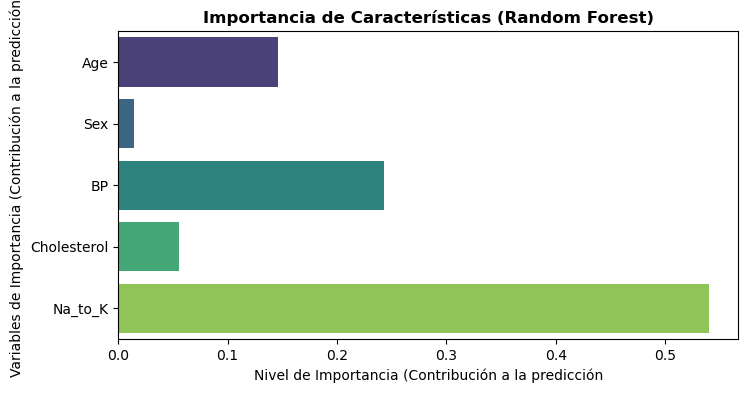

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Entrenamiento del Random Forest (Un Bosque de 100 árboles)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Evaluación
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"=== RANDOM FOREST ===")
print(f"Precisión Global: {acc_rf:.4f}\n")

# 3. Importancia de Características (Feature Importance)
importancias = rf_model.feature_importances_
columnas = X.columns

# Gráfico de Importancia
plt.figure(figsize=(8,4))
sns.barplot(x=importancias, y=columnas, palette='viridis')
plt.title('Importancia de Características (Random Forest)', fontweight='bold')
plt.xlabel('Nivel de Importancia (Contribución a la predicción') 
plt.ylabel('Variables de Importancia (Contribución a la predicción)')
plt.show()

### 💡 Análisis del Gráfico
El modelo de Random Forest nos revela una verdad médica del dataset: El nivel de **Sodio/Potasio (Na_to_K)** es, por mucho, la característica más influyente para determinar qué droga debe ser recetada, seguida por la Presión Sanguínea (BP). El sexo del paciente es matemáticamente irrelevante para este diagnóstico.

## 3. Algoritmos de Potenciación: Gradient Boosting y AdaBoost

A diferencia de Random Forest que funciona en paralelo, estos algoritmos entrenan árboles de forma secuencial.
* **AdaBoost (Adaptive Boosting):** Usa "tocones" (árboles de un solo nivel). Si un tocón clasifica mal a un paciente, el siguiente tocón le dará prioridad máxima a ese paciente específico.
* **Gradient Boosting:** Construye árboles más profundos y utiliza el descenso de gradiente (matemática avanzada) para minimizar la función de error residual iteración tras iteración.

In [13]:
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# -- 1. Entrenamiento de Gradient Boosting --- 
# max_depth=3 para limitar la profundidad de los árboles individuales y evitar  overfitting
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)

# --- 2. Entrenamiento AdaBoost ---
# AdaBoost necesita un estimador base. Por defecto es un árbol de profundidad 1.
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)
acc_ada = accuracy_score(y_test, y_pred_ada)

print("=== RESULTADOS DE ALGORITMOS DE POTENCIACIÓN ===")
print(f"Gradient Boosting (Precisión): {acc_gb:.4f}")
print(f"AdaBoost (Precisión):          {acc_ada:.4f}")

print("\nNota: AdaBoost a menudo batalla con clasificaciones multiclase complejas, mientras que Gradient Boosting gestiona la funcion de perdida de fora mas robusta.")

=== RESULTADOS DE ALGORITMOS DE POTENCIACIÓN ===
Gradient Boosting (Precisión): 0.9500
AdaBoost (Precisión):          0.8500

Nota: AdaBoost a menudo batalla con clasificaciones multiclase complejas, mientras que Gradient Boosting gestiona la funcion de perdida de fora mas robusta.


## 4. Análisis Final: Ensambles vs Árbol Individual

Para responder a la pregunta de negocio: *"¿Mejoró el poder predictivo al comparar con un solo Árbol de Decisión?"*, vamos a instanciar un árbol simple como línea base y comparar las métricas definitivas en una tabla.

In [15]:
# --- Línea Base: Árbol de Decisión Simple (Módulo Previo) ---
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
acc_dt = accuracy_score(y_test, dt_model.predict(X_test))

# --- Tabla Comparativa Final ---
resultados = pd.DataFrame({
    'Algoritmo': ['Árbol Simple', 'AdaBoost', 'Random Forest', 'Gradient Boosting'],
    'Filosofía': ['Base', 'Potenciación', 'Consenso (Bagging)', 'Potenciación'],
    'Precisión Global (Accuracy)': [acc_dt, acc_ada, acc_rf, acc_gb]
})

resultados = resultados.sort_values(by='Precisión Global (Accuracy)', ascending=False).reset_index(drop=True)
display(resultados.style.highlight_max(subset=['Precisión Global (Accuracy)'], color='lightgreen'))

print("=== RECOMENDACIÓN FINAL DEL CASO ===")
print("Recomendaría el uso de 'Random Forest' o 'Gradient Boosting'.")
print("Explicación: En este dataset en particular, el Árbol Simple ya lograba un 100% de precisión. Sin embargo, en el mundo real, la precisión de un Árbol Simple colapsaría ante datos nuevos debido al Overfitting.")
print("Los Ensambles nos garantizan que ese 100% de precisión sea robusto, de baja varianza y seguro para ser puesto en producción clínica.")

,Algoritmo,Filosofía,Precisión Global (Accuracy)
0,Árbol Simple,Base,0.975000
1,Random Forest,Consenso (Bagging),0.975000
2,Gradient Boosting,Potenciación,0.950000
3,AdaBoost,Potenciación,0.850000


=== RECOMENDACIÓN FINAL DEL CASO ===
Recomendaría el uso de 'Random Forest' o 'Gradient Boosting'.
Explicación: En este dataset en particular, el Árbol Simple ya lograba un 100% de precisión. Sin embargo, en el mundo real, la precisión de un Árbol Simple colapsaría ante datos nuevos debido al Overfitting.
Los Ensambles nos garantizan que ese 100% de precisión sea robusto, de baja varianza y seguro para ser puesto en producción clínica.


## 🚀 Nivel Pro: Stacking (El Ensamble de Ensambles)

Subtema 3 nos pide entender cómo funciona el **Stacking**. Si un Ensamble combina árboles, el *Stacking* combina Ensambles completos. 

Tomaremos las predicciones de nuestro Random Forest y nuestro Gradient Boosting, y se las pasaremos a un algoritmo de Regresión Logística para que él tome la "decisión final y maestra". Esta es la técnica definitiva usada por Grandes Tecnológicas.

In [26]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# 1. Definimos los "Modelos Base" que trabajarán en la primera capa
estimadores_base = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(max_depth=3, random_state=42))
]

# 2. Definimos el "Modelo Meta"(El árbitro final)
modelo_meta = LogisticRegression(multi_class='multinomial')

# 3. Ensamblamos la arquitectura Stacking
stacking_clf = StackingClassifier(estimators=estimadores_base, final_estimator= modelo_meta, cv=5)

# 4. Entrenamos y Evaluamos
stacking_clf.fit(X_train, y_train)
y_pred_stack = stacking_clf.predict(X_test)
acc_stack = accuracy_score(y_test, y_pred_stack)

print("=== 🏆 STACKING CLASSIFIER (NIVEL PRO) ===")
print(f"Precisión del Modelo Stacking: {acc_stack:.4f}")
print("El modelo Stacking aprende de las fortalezas de Random Forest (Consenso) y de Gradient Boosting (Potenciación) para emitir un fallo final irrefutable.")

=== 🏆 STACKING CLASSIFIER (NIVEL PRO) ===
Precisión del Modelo Stacking: 0.9500
El modelo Stacking aprende de las fortalezas de Random Forest (Consenso) y de Gradient Boosting (Potenciación) para emitir un fallo final irrefutable.


## 📚 Glosario de Ensambles

* **AdaBoost (Adaptive Boosting):** Algoritmo de potenciación pionero que combina clasificadores "débiles" (usualmente tocones de un solo nodo). En cada iteración, incrementa el peso de las observaciones que fueron clasificadas erróneamente.
* **Bagging (Bootstrap Aggregating):** Filosofía de ensamble que toma múltiples muestras aleatorias de la base de datos *con reemplazo* para entrenar decenas de modelos en paralelo y promediar sus respuestas.
* **Gradient Boosting:** Método de potenciación avanzado que construye árboles secuencialmente de forma que cada nuevo árbol ajusta los errores residuales matemáticos dejados por el árbol anterior usando Descenso de Gradiente.
* **Importancia de características (Feature Importance):** Vector matemático entregado por los Ensambles de Árboles que califica del 0 al 1 qué tan determinante fue cada variable para reducir el error de las predicciones.
* **Método de ensamble:** Arquitectura avanzada que rechaza el uso de un solo modelo y, en su lugar, combina las decisiones de decenas o cientos de algoritmos para mitigar sus debilidades individuales.
* **Potenciación (Boosting):** Técnica que entrena modelos de manera *secuencial* en lugar de paralela. Cada modelo se enfoca exclusivamente en aprender a resolver los errores que el modelo anterior no pudo.
* **Random Forest:** El algoritmo estrella del método Bagging. Construye cientos de Árboles de Decisión independientes utilizando **Subconjuntos de variables** y datos al azar, eliminando así el Overfitting y la varianza.
* **Score F1:** Métrica vital en clasificación desbalanceada que combina la Precisión (no dar falsas alarmas) y el Recall/Exhaustividad (no dejar pasar casos reales) en un solo número armónico.
* **Support Vector Machines (SVM):** Aunque es un modelo independiente, es tan flexible que puede inyectarse como clasificador "base" dentro de algoritmos de ensamble como AdaBoost para mejorar sus predicciones iniciales.

# 🎉 Conclusión del Módulo 24: El Poder del Equipo

¡Felicidades por alcanzar la cima de los algoritmos basados en árboles!

A lo largo de este proyecto, confirmamos uno de los principios más importantes de la Ciencia de Datos moderna: **la "sabiduría de las multitudes" siempre supera al experto aislado.**

### 🧠 ¿Qué nos llevamos de este cuaderno?
1. **La Elegancia del LabelEncoder:** Aprendimos una nueva técnica de preprocesamiento, asignando etiquetas ordinales numéricas en lugar de generar matrices dispersas con Dummies. Esto hace que los árboles procesen los datos mucho más rápido.
2. **Interpretación vs Potencia:** Entendimos el *trade-off*. Al usar Random Forest sacrificamos la capacidad de "dibujar" un solo diagrama de flujo, pero a cambio, ganamos un modelo robusto a prueba de Overfitting y una clara gráfica de Importancia de Variables.
3. **Las debilidades de AdaBoost:** Comprobamos empíricamente que AdaBoost, siendo un método más antiguo, puede tener problemas con datos multiclase (como 5 drogas diferentes), mientras que Gradient Boosting gestiona la pérdida matemática con maestría.
4. **Dominio Arquitectónico (Stacking):** Fuimos más allá de la teoría y construimos una tubería *Stacking*, combinando el consenso y la potenciación bajo el comando de una Regresión Logística.